<a href="https://colab.research.google.com/github/Pradeep-Kumar-Panga/DecodingComplexities/blob/main/MaximumLikelihoodEstimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Maximum Likelihood Estimation
Maximum Likelihood Estimation (MLE) is a statistical method for estimating the parameters of a probability distribution by maximizing a likelihood function, making the observed data most probable under the assumed model. It determines parameter values (e.g., mean, variance) that best fit the data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

**Generate the Data**

Generate the data that follows a normal distribution, with a mean of 150 and a standard deviation of 10 using NumPy.

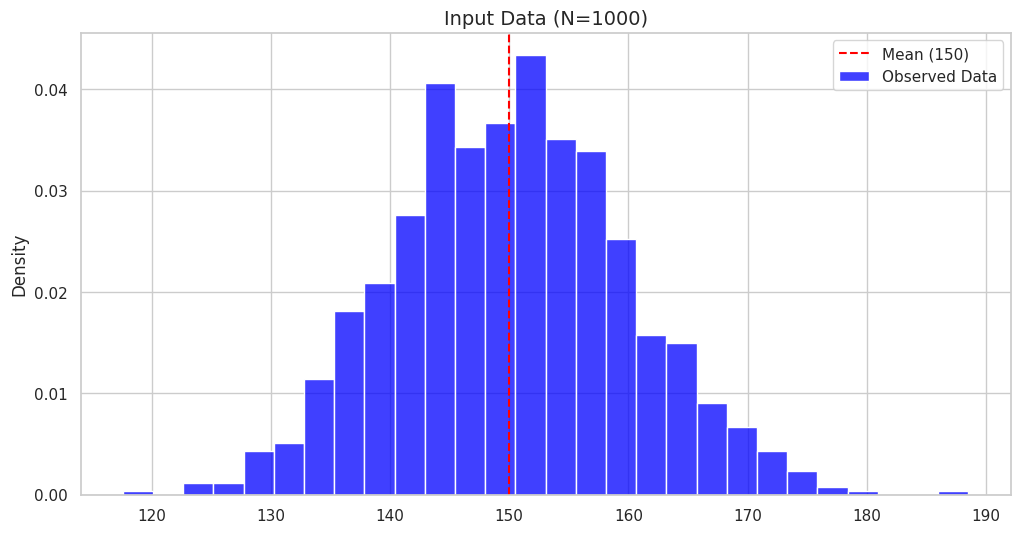

In [2]:
np.random.seed(42)
true_mean = 150
standard_deviation = 10
no_of_samples = 1000

# Generate the observed data
data = np.random.normal(true_mean, standard_deviation, no_of_samples)

# Visualize the Data
plt.figure()
sns.histplot(data, stat="density", color="blue", label="Observed Data")
plt.axvline(true_mean, color='red', linestyle='--', label=f"Mean ({true_mean})")
plt.title(f"Input Data (N={no_of_samples})", fontsize=14)
plt.legend()
plt.show()

# Calculate the Likelihood of the Distribution
Likelihood of the data distribution is equal to the product of the probability distribution of each data point in the distribution.

As the population size increases, the product of the probabilities tend to be zero.

L(theta) = P(x1) * P(x2) * . . . * P(xn)

In [3]:
def calculate_likelihood(data, mean, standard_deviation):
    # Get probability density for every point
    probabilities = norm.pdf(data, loc=mean, scale=standard_deviation)
    # Multiply them all probabilities
    return np.prod(probabilities)

# Calculate the likelihood for the input data
naive_likelihood = calculate_likelihood(data, true_mean, standard_deviation)

print(f"Multiplying {no_of_samples} probabilities together...")
print(f"Likelihood (Product of Probabilities): {naive_likelihood}")
print("Product of probabilities is too small, it has been rounded to zero.\n")

Multiplying 1000 probabilities together...
Likelihood (Product of Probabilities): 0.0
Product of probabilities is too small, it has been rounded to zero.



# Log-Likelihood
To avoid the Likelihood becoming zero, we take the log of likehood function.

Taking the log of likehood would require the sum of log of individual probabilities instead of the product.

LL(theta) = log(P(x1)) + log (P(x2)) + ... + log(P(xn))

In [4]:
def calculate_log_likelihood(data, mean, standard_deviation):
    probabilities = norm.pdf(data, loc=mean, scale=standard_deviation)
    # Take Log first, then Sum (Turns multiplication into addition)
    return np.sum(np.log(probabilities))

# Calculate again
log_likelihood = calculate_log_likelihood(data, true_mean, standard_deviation)

print(f"Log-Likelihood Result: {log_likelihood:.2f}")
print("We get a stable, negative number. We can optimize this.\n")

Log-Likelihood Result: -3700.66
We get a stable, negative number. We can optimize this.



# Finding the Maximum Likelihood
We have calculated the Log-Likelihood for the true mean of the data. Do we assume that as the the maximum likelihood?

Let's calculate log-likelihood for different mean guesses and validate if the maximum likelihood matches with the likelihood calculated for the True mean of the data.

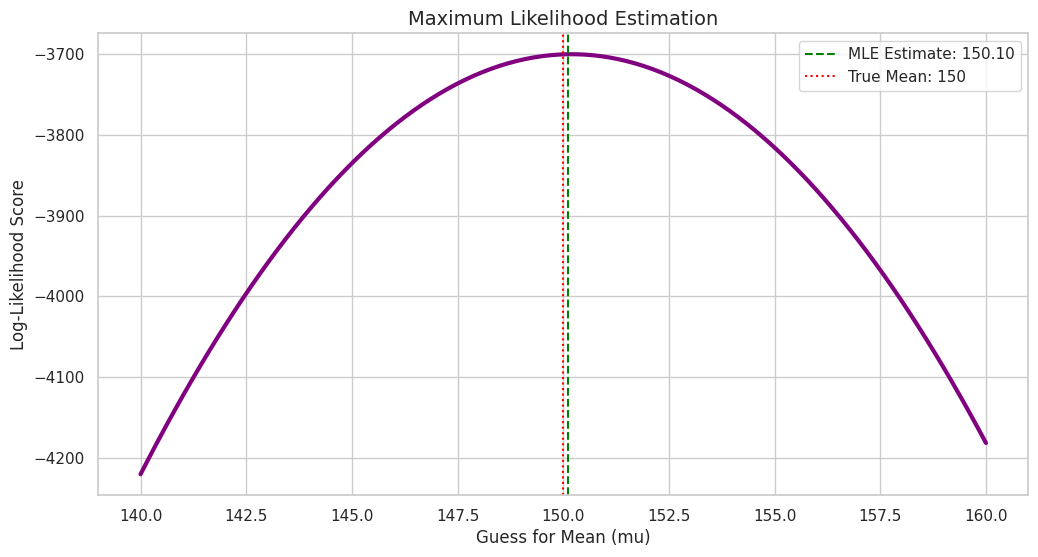

Best mean according to the Likelihood Estimate: 150.10
Actual True Mean: 150


In [5]:
# Create a range of guesses from 140 to 160
mean_guesses = np.linspace(140, 160, 100)
ll_scores = []

# Calculate Log-Likelihood score for each guess
for mean in mean_guesses:
    score = calculate_log_likelihood(data, mean, standard_deviation)
    ll_scores.append(score)

# Find the best guess (Maximum)
best_idx = np.argmax(ll_scores)
best_mean = mean_guesses[best_idx]

# Visualize the Log-Likelihood
plt.figure()
plt.plot(mean_guesses, ll_scores, color='purple', linewidth=3)
plt.axvline(best_mean, color='green', linestyle='--', label=f"MLE Estimate: {best_mean:.2f}")
plt.axvline(true_mean, color='red', linestyle=':', label=f"True Mean: {true_mean}")
plt.title("Maximum Likelihood Estimation", fontsize=14)
plt.xlabel("Guess for Mean (mu)")
plt.ylabel("Log-Likelihood Score")
plt.legend()
plt.show()

print(f"Best mean according to the Likelihood Estimate: {best_mean:.2f}")
print(f"Actual True Mean: {true_mean}")

# MLE vs MSE
Calculate the Mean Squared Error for the same mean guesses to compare how Mean Squared Error get along with Likelihood.

Does Maximum Likelihood Estimate match with the Minimum Mean Squared Error?

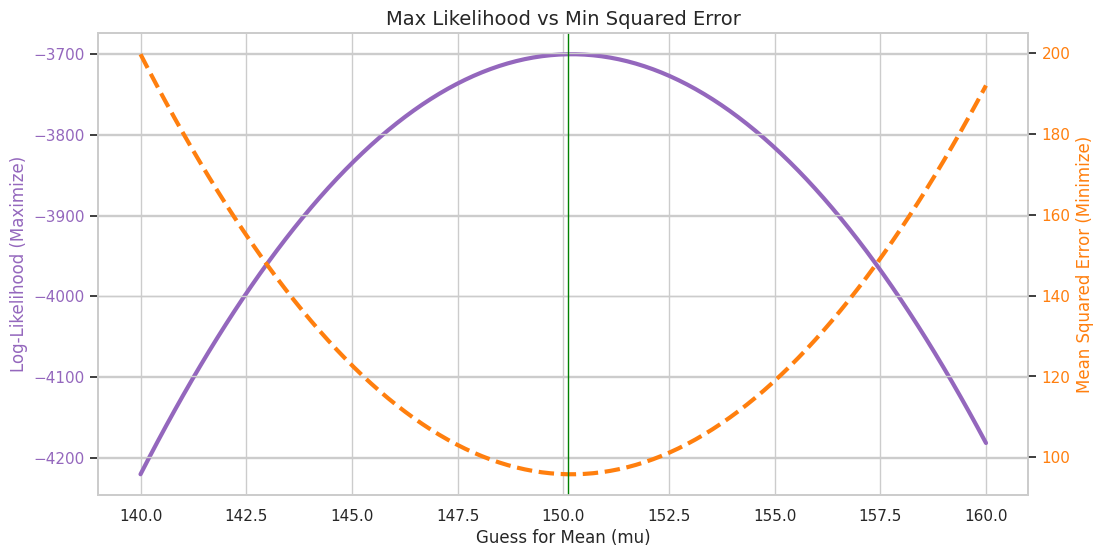


The Peak of Likelihood aligns PERFECTLY with the Bottom of MSE.


In [6]:
def calculate_mse(data, mean_guess):
    errors = data - mean_guess
    squared_errors = errors ** 2
    return np.mean(squared_errors)

mse_scores = [calculate_mse(data, mean) for mean in mean_guesses]

# Plot side-by-side
fig, ax1 = plt.subplots()

color = 'tab:purple'
ax1.set_xlabel('Guess for Mean (mu)')
ax1.set_ylabel('Log-Likelihood (Maximize)', color=color)
ax1.plot(mean_guesses, ll_scores, color=color, linewidth=3, label="Log Likelihood")
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_title("Max Likelihood vs Min Squared Error", fontsize=14)

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Mean Squared Error (Minimize)', color=color)
ax2.plot(mean_guesses, mse_scores, color=color, linewidth=3, linestyle='--', label="MSE")
ax2.tick_params(axis='y', labelcolor=color)

# Draw the line where they align
plt.axvline(best_mean, color='green', linestyle='-', linewidth=1)
plt.show()

print("\nThe Peak of Likelihood aligns PERFECTLY with the Bottom of MSE.")